<a href="https://colab.research.google.com/github/M90X-2/IT480-FA26/blob/main/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Maximilian Vogel

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [5]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [6]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?  

 There are 755 images in the fire_images class and 244 images in non_fire_images. There is signifigant class imbalance so a random split would not be good as you could possibly have a set with very little non_fire_images. A stratified split would be best for this dataset. Becuase of the dataset being skewed, accuracy could be misleading, a confusion matrix would probably be best for this data.

Write whatever code you need to answer this for yourself.

In [7]:
import os

for cls in class_names_fire:
    count = len(os.listdir(os.path.join(data_dir_fire, cls)))
    print(f"{cls}: {count} images")

import matplotlib.pyplot as plt

for images, labels in train_raw_fire.take(1):
    print(f"Shape of the image batch: {images.shape}")

fire_images: 755 images
non_fire_images: 244 images
Shape of the image batch: (32, 224, 224, 3)


*What did you notice about this dataset? Does it change how you'll approach the next steps?*   My suspicions were confirmed with the dataset being heavily skewed toward the fire_images class. I aso now due to the shape of the image batch that the images are in color and not black and white. Also because it is two classes I can use binary cross entropy.



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [8]:
# Preprocess the data here
def preprocess(image, label):
    return preprocess_input(image), label

train_fire = train_raw_fire.map(preprocess)
val_fire = val_raw_fire.map(preprocess)
test_fire = test_raw_fire.map(preprocess)


In [9]:
# Build your model here
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# Compile your model here

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [11]:
# Train your model here
history = model.fit(
    train_fire,
    epochs=10,
    validation_data=val_fire
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8057 - loss: 0.3853 - val_accuracy: 0.9065 - val_loss: 0.2482
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 545ms/step - accuracy: 0.9457 - loss: 0.1671 - val_accuracy: 0.9496 - val_loss: 0.1428
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 548ms/step - accuracy: 0.9600 - loss: 0.1155 - val_accuracy: 0.9568 - val_loss: 0.1044
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step - accuracy: 0.9757 - loss: 0.0912 - val_accuracy: 0.9640 - val_loss: 0.0900
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 546ms/step - accuracy: 0.9814 - loss: 0.0772 - val_accuracy: 0.9784 - val_loss: 0.0783
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 601ms/step - accuracy: 0.9886 - loss: 0.0676 - val_accuracy: 0.9568 - val_loss: 0.0964
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 565ms/step - accuracy: 0.9886 - loss: 0.0612 - val_accuracy: 0.9496 - val_loss: 0.0948
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 665ms/step - accuracy: 0.9914 - loss: 0.0545 - val_accurac

In [12]:
# Report validation and test accuracy here
val_loss, val_acc = model.evaluate(val_fire)
test_loss, test_acc = model.evaluate(test_fire)

print(f"Validation Accuracy: {val_acc}")
print(f"Test Accuracy: {test_acc}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.9640 - loss: 0.0639
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.9625 - loss: 0.0750
Validation Accuracy: 0.9640287756919861
Test Accuracy: 0.9624999761581421


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

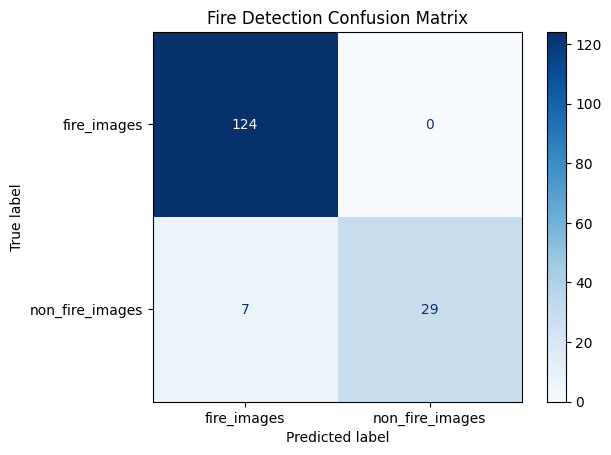

In [13]:
# Build your confusion matrix here
y_true = []
y_pred = []

for images, labels in test_fire:
    y_true.extend(labels.numpy())

    batch_preds = model.predict(images, verbose=0)
    y_pred.extend((batch_preds > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap=plt.cm.Blues)
plt.title("Fire Detection Confusion Matrix")
plt.show()

*Your answer:* A false negatvie will alwways be more costly as missing a real fire could result in peoples lives being at risk potentially. Due to a false negative being more costly lowering the decision threshold from 0.5 might be beneficial as it coud lead to less false negatvies, although it would increase false positives.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [14]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


In [15]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [16]:
# Preprocess the data here
def preprocess_sat(image, label):
    return preprocess_input(image), label

train_sat = train_raw_sat.map(preprocess_sat)
val_sat = val_raw_sat.map(preprocess_sat)
test_sat = test_raw_sat.map(preprocess_sat)

In [17]:
# Build your model here
base_model_sat = MobileNetV2(input_shape=(224, 224, 3),
                             include_top=False,
                             weights='imagenet')

base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)


outputs = Dense(10, activation='softmax')(x)

model_sat = Model(inputs, outputs)

In [18]:
# Compile your model here
model_sat.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [19]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    epochs=10,
    validation_data=val_sat
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.8789 - loss: 0.3731 - val_accuracy: 0.9309 - val_loss: 0.2138
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.9334 - loss: 0.1960 - val_accuracy: 0.9393 - val_loss: 0.1867
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9470 - loss: 0.1598 - val_accuracy: 0.9390 - val_loss: 0.1817
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9543 - loss: 0.1386 - val_accuracy: 0.9413 - val_loss: 0.1807
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9604 - loss: 0.1220 - val_accuracy: 0.9420 - val_loss: 0.1743
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9642 - loss: 0.1103 - val_accuracy: 0.9376 - val_loss: 0.1831
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.9689 - loss: 0.0990 - val_accuracy: 0.9383 - val_loss: 0.1829
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.9710 - loss: 0.0920 - 

In [24]:
# Report validation and test accuracy here
val_loss, val_acc = model_sat.evaluate(val_sat)
test_loss, test_acc = model_sat.evaluate(test_sat)

print(f"Validation Accuracy: {val_acc}")
print(f"Test Accuracy: {test_acc}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9435 - loss: 0.1747
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9419 - loss: 0.1737
Validation Accuracy: 0.9435084462165833
Test Accuracy: 0.9419291615486145


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

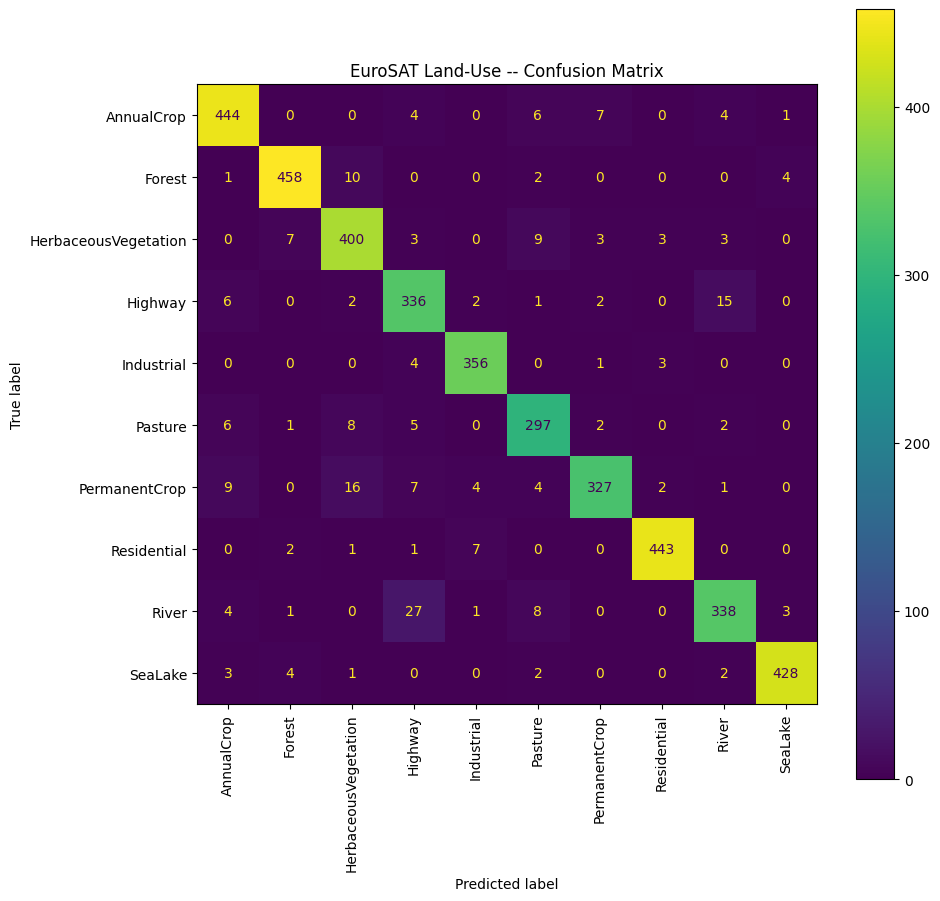

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
final_preds = []

for images, labels in test_sat:
    y_true.extend(labels.numpy())

    batch_probs = model_sat.predict(images, verbose=0)
    batch_preds = np.argmax(batch_probs, axis=1)
    final_preds.extend(batch_preds)

cm_sat = confusion_matrix(y_true, final_preds)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)

disp.plot(ax=ax, xticks_rotation='vertical')

plt.title("EuroSAT Land-Use -- Confusion Matrix")
plt.show()

*Your answer:* The model gets confused most often with the classes highway with river and herbaceousvegetation, forest, and pasture get confused with each other. It majes sense if thining from a top down perspective as highways and rivers woud look similar with long narrow stretches.



---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |0.9640| 0.9435|
| Test Accuracy |0.9625 |0.9419 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
1. The fire dataset is much closer to ImageNet's original training because they both consist of ground level photographs. The EuroSat set is a greater mismatch becuase it consists of top down images. This is reflected in the fire dataset gaining a hgher test accuracy of 96.25% to eurosat's 94.19%

2. There is room for improvement in both datasets if you were to unfreeze and adjust the base models weights. This would matter much more for the eurosat dataset as it was furthest away from the Imagenet training out of the two.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
The large class imbalance in the fire dataset required me to evaluate the model with a confusion matrix in order to gain a better understanding on how accurate it actually was because raw accuracy would be misleading. It also highlighted the need for stratified data. Part 1 only needed a single output node with sigmoid activation and binary cross-entropy, while part 2 need 10 output nodes with softmax activation and sparse categorical cross-entropy. A pretrained model's usefulness largely depends on how well the original training data matches the new data. This is evidenced by how the fire dataset garnered higher results at 96.25% compared to the eurosat at 94.19% due to how closely the datasets matched the original.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.